In [20]:
#!pip install langgraph

In [2]:
from typing import TypedDict

In [3]:
class SomeState(TypedDict):
  att1:str
  att2:str

In [4]:
def some_function(state:SomeState):
  state['att1']="Value changed by node some_function()"
  return state

In [5]:
from langgraph.graph import StateGraph

In [6]:
graph=StateGraph(SomeState)

In [7]:
graph.add_node("node1",some_function)

In [8]:
from langgraph.graph import END

In [9]:
graph.add_edge("node1",END)

In [10]:
graph.set_entry_point('node1')

In [11]:
compiled_graph=graph.compile()

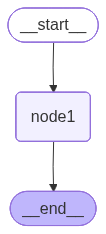

In [12]:
compiled_graph

In [15]:
##

In [1]:
from typing import TypedDict

In [2]:
class State(TypedDict):
  graph_state:str

In [3]:
def first_node(state):
  print("This is my first node")
  return {"graph_state":state['graph_state']+"Hi, I am travelling"}

In [4]:
def second_node(state):
  print("This is my second node")
  return {"graph_state":state['graph_state']+"Meghalaya - India"}

In [5]:
def third_node(state):
  print("This is my third node")
  return {"graph_state":state['graph_state']+"Kerala- India"}

In [24]:
# Logic

In [6]:
import random

In [7]:
from typing import Literal

In [8]:
def decide_location(state)->Literal['second_node','third_node']:
  graph_state=state['graph_state']
  if random.random()<0.5:
    return 'second_node'
  else:
    return 'third_node'

In [9]:
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

In [10]:
builder=StateGraph(State)

In [11]:
builder.add_node("first_node",first_node)
builder.add_node("second_node",second_node)
builder.add_node("third_node",third_node)

In [12]:
builder.add_edge(START,"first_node")
builder.add_conditional_edges("first_node",decide_location)

In [13]:
builder.add_edge("second_node",END)
builder.add_edge("third_node",END)

In [14]:
graph=builder.compile()

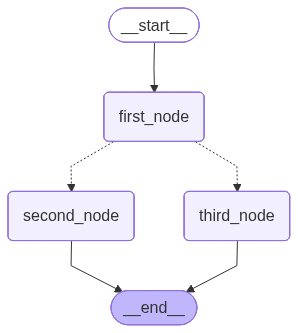

In [15]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
graph.invoke({"graph_state":"Hi, My name is Abhijeet"})

This is my first node
This is my third node


{'graph_state': 'Hi, My name is AbhijeetHi, I am travellingKerala- India'}

In [17]:
graph.invoke({"graph_state":"Hi, My name is Abhijeet"})

This is my first node
This is my second node


{'graph_state': 'Hi, My name is AbhijeetHi, I am travellingMeghalaya - India'}

In [18]:
graph.invoke({"graph_state":"Hi, My name is Abhijeet"})

This is my first node
This is my third node


{'graph_state': 'Hi, My name is AbhijeetHi, I am travellingKerala- India'}